In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from datetime import datetime

def scrape_finviz_full_market(pages_to_scrape=3):
    all_stocks = []
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Referer': 'https://finviz.com/screener.ashx',
        'Connection': 'keep-alive',
    }

    for page in range(pages_to_scrape):
        start_row = (page * 20) + 1
        url = f"https://finviz.com/screener.ashx?v=111&r={start_row}"
        
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Scraping {url}...")
        
        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            soup = BeautifulSoup(response.text, 'html.parser')

            table = soup.find('table', class_='screener_table')
            
            if not table:
                print(f"⚠️ Could not find table on page {page+1}. Finviz might be blocking the request.")
                if "Cloudflare" in response.text or "unusual activity" in response.text:
                    print("❌ Blocked by Bot Detection. Try increasing the time.sleep() or using a proxy.")
                break

            rows = table.find_all('tr', class_='styled-row')

            for row in rows:
                cols = row.find_all('td')
                if len(cols) >= 11:
                    all_stocks.append({
                        'No': cols[0].text.strip(),
                        'Ticker': cols[1].text.strip(),
                        'Company': cols[2].text.strip(),
                        'Sector': cols[3].text.strip(),
                        'Industry': cols[4].text.strip(),
                        'Country': cols[5].text.strip(),
                        'Market Cap': cols[6].text.strip(),
                        'P/E': cols[7].text.strip(),
                        'Price': cols[8].text.strip(),
                        'Change': cols[9].text.strip(),
                        'Volume': cols[10].text.strip()
                    })

            time.sleep(5) 

        except Exception as e:
            print(f"Error: {e}")
            break

    df = pd.DataFrame(all_stocks)
    
    if not df.empty:
        filename = f"finviz_market_data_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
        df.to_csv(filename, index=False)
        print(f"\n✅ SUCCESS: Collected {len(df)} stocks.")
        print(f"📂 Saved to: {filename}")
        print(df.head())
    else:
        print("\n❌ No data was collected.")

if __name__ == "__main__":
    scrape_finviz_full_market(pages_to_scrape=50)

[14:33:51] Scraping https://finviz.com/screener.ashx?v=111&r=1...
[14:33:58] Scraping https://finviz.com/screener.ashx?v=111&r=21...
[14:34:04] Scraping https://finviz.com/screener.ashx?v=111&r=41...
[14:34:11] Scraping https://finviz.com/screener.ashx?v=111&r=61...
[14:34:17] Scraping https://finviz.com/screener.ashx?v=111&r=81...
[14:34:23] Scraping https://finviz.com/screener.ashx?v=111&r=101...
[14:34:30] Scraping https://finviz.com/screener.ashx?v=111&r=121...
[14:34:36] Scraping https://finviz.com/screener.ashx?v=111&r=141...
[14:34:42] Scraping https://finviz.com/screener.ashx?v=111&r=161...
[14:34:48] Scraping https://finviz.com/screener.ashx?v=111&r=181...
[14:34:54] Scraping https://finviz.com/screener.ashx?v=111&r=201...
[14:35:00] Scraping https://finviz.com/screener.ashx?v=111&r=221...
[14:35:06] Scraping https://finviz.com/screener.ashx?v=111&r=241...
[14:35:12] Scraping https://finviz.com/screener.ashx?v=111&r=261...
[14:35:18] Scraping https://finviz.com/screener.ashx?v

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. LOAD DATA
# df = pd.read_csv('your_finviz_file.csv') 
# For now, I'll assume 'df' is already in your memory from the scrape

# 2. ROBUST CLEANING
def clean_market_data(df_raw):
    df = df_raw.copy()
    
    # Helper to convert Market Cap (B/M) to numbers
    def parse_suffix(val):
        if pd.isna(val) or val == '-': return np.nan
        val = str(val).upper()
        if 'B' in val: return float(val.replace('B', '')) * 1e9
        if 'M' in val: return float(val.replace('M', '')) * 1e6
        if 'K' in val: return float(val.replace('K', '')) * 1e3
        return pd.to_numeric(val, errors='coerce')

    # Clean the columns
    df['Change_Pct'] = pd.to_numeric(df['Change'].str.replace('%', ''), errors='coerce')
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'].str.replace(',', ''), errors='coerce')
    df['PE_Ratio'] = pd.to_numeric(df['P/E'], errors='coerce')
    df['Market_Cap_USD'] = df['Market Cap'].apply(parse_suffix)
    
    # Drop rows where we have no price or change data (the "empty" rows)
    df = df.dropna(subset=['Change_Pct', 'Price'])
    
    # Fill missing P/E with the median (common DS practice to keep data)
    df['PE_Ratio'] = df['PE_Ratio'].fillna(df['PE_Ratio'].median())
    
    return df

df_clean = clean_market_data(df)

# 3. FEATURE ENGINEERING
# Let's create a 'Volume Intensity' feature: Volume relative to Market Cap
# This helps find stocks with "unusual" interest today
df_clean['Vol_Intensity'] = df_clean['Volume'] / (df_clean['Market_Cap_USD'] + 1)

# 4. ANALYTICS: Sector Performance
print("\n--- SECTOR PERFORMANCE ---")
sector_summary = df_clean.groupby('Sector')['Change_Pct'].mean().sort_values(ascending=False)
print(sector_summary)

# 5. MACHINE LEARNING: K-Means Clustering
# We want to group stocks into 3 categories: Value, Growth, and Volatile
features = ['Change_Pct', 'Price', 'PE_Ratio']
X = df_clean[features]

# Standardize data (Mandatory for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = model.fit_predict(X_scaled)

print("\n--- CLUSTER PROFILES ---")
print(df_clean.groupby('Cluster')[features].mean())

# 6. SAVE THE SMART DATA
df_clean.to_csv('finviz_analyzed_1000.csv', index=False)
print("\n✅ Analysis complete! Saved to 'finviz_analyzed_1000.csv'")


--- SECTOR PERFORMANCE ---
Sector
Consumer Defensive        3.313500
Communication Services    1.350476
Technology                1.322424
Energy                    1.293077
Real Estate               0.858966
Healthcare                0.392645
Basic Materials           0.314545
Financial                 0.143709
Industrials              -0.102468
Utilities                -0.165455
Consumer Cyclical        -1.507959
Name: Change_Pct, dtype: float64

--- CLUSTER PROFILES ---
         Change_Pct    Price    PE_Ratio
Cluster                                 
0          0.332608    43.59    30.60006
1         -4.480000     8.95  6884.62000
2         -0.760000  3400.54    23.82000

✅ Analysis complete! Saved to 'finviz_analyzed_1000.csv'


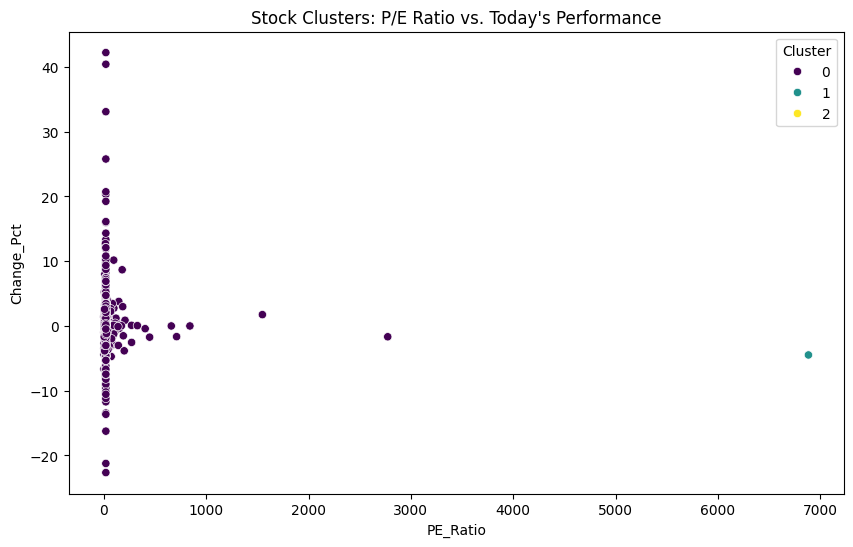

In [9]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='PE_Ratio', y='Change_Pct', hue='Cluster', palette='viridis')
plt.title('Stock Clusters: P/E Ratio vs. Today\'s Performance')
plt.show()

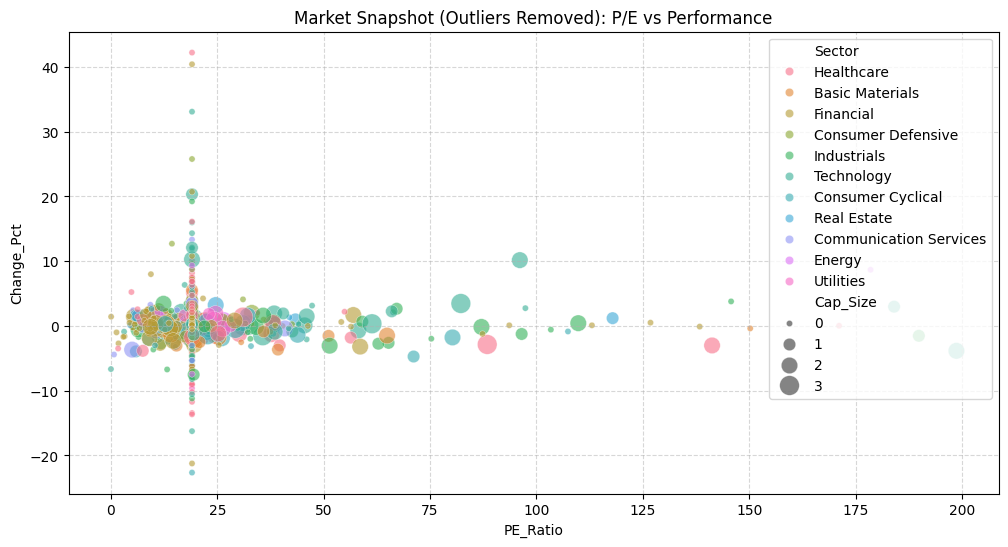


--- FEATURE IMPORTANCE (What moves the price today?) ---
         Feature  Importance
2  Vol_Intensity    0.482821
1          Price    0.475261
0       PE_Ratio    0.034312
3       Cap_Size    0.007606


In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data you just saved
df = pd.read_csv('finviz_analyzed_1000.csv')

# --- 1. CLEANING THE OUTLIERS ---
# Stocks with P/E > 500 or Price > 1000 usually break ML models.
df_filtered = df[(df['PE_Ratio'] < 200) & (df['Price'] < 1000)].copy()

# --- 2. ADVANCED FEATURE ENGINEERING ---
# Create 'Market Cap Category' (Ordinal Encoding)
def cap_category(val):
    if val > 2e11: return 3 # Mega
    if val > 1e10: return 2 # Large
    if val > 2e9: return 1  # Mid
    return 0                # Small/Micro

df_filtered['Cap_Size'] = df_filtered['Market_Cap_USD'].apply(cap_category)

# Create 'Price Momentum'
# If price is high and change is positive, it's a 'Runner'
df_filtered['Momentum_Score'] = df_filtered['Change_Pct'] * np.log1p(df_filtered['Volume'])

# --- 3. ML MODEL: RANDOM FOREST (What drives price change?) ---
# We want to see which features actually influence Today's Change
features = ['PE_Ratio', 'Price', 'Vol_Intensity', 'Cap_Size']
X = df_filtered[features].fillna(0)
y = df_filtered['Change_Pct']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get Feature Importance
importance = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

# --- 4. VISUALIZATION: THE 'ZOOMED' MARKET ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_filtered, x='PE_Ratio', y='Change_Pct', 
                hue='Sector', size='Cap_Size', sizes=(20, 200), alpha=0.6)
plt.title('Market Snapshot (Outliers Removed): P/E vs Performance')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\n--- FEATURE IMPORTANCE (What moves the price today?) ---")
print(importance)